# k-Nearest Neighbours and Naive Bayes

Two classical algorithms that sit at opposite ends of the design space, and both worth knowing properly.

* **k-NN** learns nothing at training time and stores everything. It is the purest form of "similar inputs have similar outputs".
* **Naive Bayes** builds an explicit probabilistic model of how the data was generated, using an assumption that is almost always false — and works anyway.

Between them they cover the two great families of classifier: **instance-based** and **generative**. They are also the two fastest baselines you can put on a new problem, which is the most practical reason to know them.

**Prerequisites:** linear and logistic regression, cross-validation, the train/validation/test discipline, precision/recall.

| Part | Topic |
|---|---|
| 1 | k-NN: distance, `k`, and the decision boundary. From scratch |
| 2 | What k-NN is bad at: scale, dimension, and cost |
| 3 | Naive Bayes: Bayes' rule, the naive assumption, and why it survives being wrong |
| 4 | Gaussian, Multinomial and Bernoulli Naive Bayes, from scratch |
| 5 | Generative vs discriminative: Naive Bayes against logistic regression |
| 6 | **Six challenge problems** |
| 7 | Summary, exercises, resources |

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

RED, BLUE, GREEN, PURPLE, GREY = "#e05252", "#3a7ddc", "#2fa84f", "#7a4fbf", "#888888"
from matplotlib.colors import ListedColormap
CMAP_PTS = ListedColormap([RED, BLUE])
CMAP_BG = ListedColormap(["#f7d7d7", "#d7e2f7"])

import sklearn
print("numpy", np.__version__, "| sklearn", sklearn.__version__)

numpy 2.5.2 | sklearn 1.9.0


---

# Part 1 — k-Nearest Neighbours

## 1.1 The whole algorithm, in three lines

To predict the label of a new point $\mathbf{x}$:

1. compute the distance from $\mathbf{x}$ to every training point,
2. take the $k$ closest,
3. return the majority vote of their labels (classification) or their mean (regression).

That is the entire method. There is no training step, no loss function, no gradient. **k-NN is a "lazy learner"**: `fit()` just stores the data, and all the work happens at prediction time. That is the opposite of every model in the previous notebooks, and it has consequences we will spend Part 2 on.

Despite the simplicity it is not a toy. With enough data, 1-NN's error rate is provably at most **twice** the Bayes-optimal error — a remarkable guarantee for an algorithm you can write in five lines.

## 1.2 Distance

Everything depends on what "close" means.

| Metric | Formula | Use for |
|---|---|---|
| **Euclidean** ($L_2$) | $\sqrt{\sum_j (x_j - z_j)^2}$ | the default, for continuous features |
| **Manhattan** ($L_1$) | $\sum_j \lvert x_j - z_j\rvert$ | high dimensions, grid-like data; more robust to outliers |
| **Minkowski** ($L_p$) | $(\sum_j \lvert x_j - z_j\rvert^p)^{1/p}$ | the family containing both above |
| **Cosine** | $1 - \frac{\mathbf{x}\cdot\mathbf{z}}{\|\mathbf{x}\|\|\mathbf{z}\|}$ | text and other sparse data, where direction matters and length does not |
| **Hamming** | count of differing positions | categorical or binary features |

The choice matters. The picture below shows the set of points at distance 1 from the origin under each metric — the "unit ball" — and each one implies a different notion of neighbourhood.

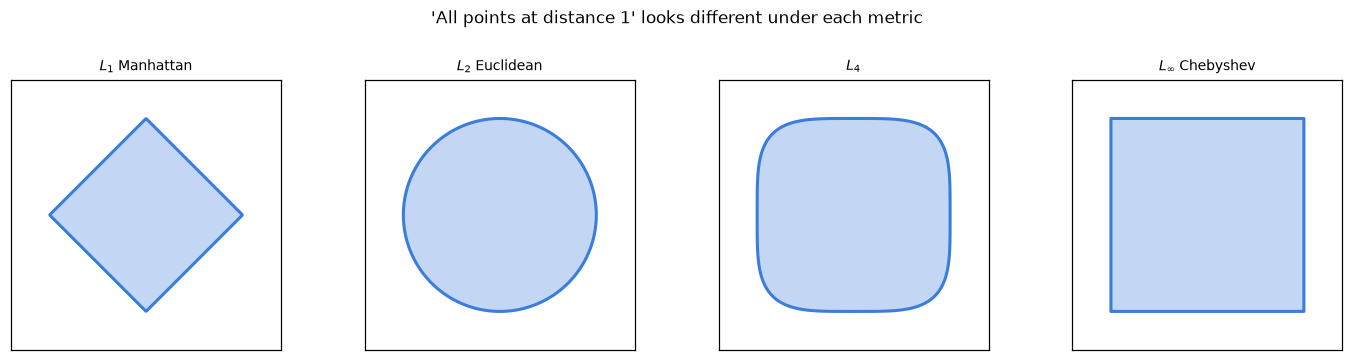

In [2]:
theta = np.linspace(0, 2 * np.pi, 500)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.1))
for ax, p, name in zip(axes, [1, 2, 4, np.inf], ["$L_1$ Manhattan", "$L_2$ Euclidean",
                                                "$L_4$", "$L_\\infty$ Chebyshev"]):
    g = np.linspace(-1.4, 1.4, 400)
    XX, YY = np.meshgrid(g, g)
    if np.isinf(p):
        D = np.maximum(np.abs(XX), np.abs(YY))
    else:
        D = (np.abs(XX) ** p + np.abs(YY) ** p) ** (1 / p)
    ax.contourf(XX, YY, (D <= 1).astype(float), levels=[0.5, 1.5], colors=[BLUE], alpha=0.3)
    ax.contour(XX, YY, D, levels=[1], colors=[BLUE], linewidths=2)
    ax.set_aspect("equal"); ax.set_title(name, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("'All points at distance 1' looks different under each metric", y=1.04)
plt.tight_layout(); plt.show()

## 1.3 From scratch

The implementation is short enough that nothing is hidden. Two details worth noticing in the code:

* **Vectorized distances.** We use $\|\mathbf{x}-\mathbf{z}\|^2 = \|\mathbf{x}\|^2 + \|\mathbf{z}\|^2 - 2\mathbf{x}^\top\mathbf{z}$ so that all distances come from a single matrix product rather than a Python loop. This is the difference between seconds and minutes.
* **`np.argpartition` instead of `np.argsort`.** We only need the $k$ smallest, not a full ordering: $O(m)$ instead of $O(m\log m)$.

In [3]:
class KNN:
    """k-nearest neighbours for classification and regression."""

    def __init__(self, k=5, task="classification", weights="uniform", p=2):
        assert task in ("classification", "regression")
        assert weights in ("uniform", "distance")
        self.k, self.task, self.weights, self.p = k, task, weights, p

    def fit(self, X, y):
        """'Training' is just memorizing. This is why k-NN is called a lazy learner."""
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y)
        self.classes_ = np.unique(self.y) if self.task == "classification" else None
        return self

    def _distances(self, Z):
        if self.p == 2:                                   # fast path: one matrix product
            d2 = (Z ** 2).sum(1)[:, None] + (self.X ** 2).sum(1)[None, :] - 2 * Z @ self.X.T
            return np.sqrt(np.maximum(d2, 0))
        return np.abs(Z[:, None, :] - self.X[None, :, :]).__pow__(self.p).sum(2) ** (1 / self.p)

    def _neighbours(self, Z):
        D = self._distances(np.asarray(Z, dtype=float))
        idx = np.argpartition(D, self.k - 1, axis=1)[:, :self.k]   # k smallest, unordered
        return idx, np.take_along_axis(D, idx, axis=1)

    def _weights(self, dist):
        if self.weights == "uniform":
            return np.ones_like(dist)
        return 1.0 / (dist + 1e-12)                       # closer neighbours count more

    def predict_proba(self, Z):
        idx, dist = self._neighbours(Z)
        w = self._weights(dist)
        labels = self.y[idx]
        out = np.zeros((len(idx), len(self.classes_)))
        for c_i, c in enumerate(self.classes_):
            out[:, c_i] = (w * (labels == c)).sum(1)
        return out / out.sum(1, keepdims=True)

    def predict(self, Z):
        idx, dist = self._neighbours(Z)
        if self.task == "regression":
            w = self._weights(dist)
            return (w * self.y[idx]).sum(1) / w.sum(1)
        return self.classes_[self.predict_proba(Z).argmax(1)]

    def score(self, Z, y):
        pred = self.predict(Z)
        if self.task == "regression":
            return 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        return float(np.mean(pred == y))


# check against sklearn
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=300, noise=0.28, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

ours = KNN(k=5).fit(Xtr, ytr)
theirs = KNeighborsClassifier(n_neighbors=5).fit(Xtr, ytr)
print(f"ours   : {ours.score(Xte, yte)*100:.2f}%")
print(f"sklearn: {theirs.score(Xte, yte)*100:.2f}%")
print(f"identical predictions: {np.array_equal(ours.predict(Xte), theirs.predict(Xte))}")

ours   : 95.56%
sklearn: 95.56%
identical predictions: True


## 1.4 What `k` controls

`k` is the only real hyperparameter, and it is a straight bias-variance dial:

* **$k = 1$** — zero training error by construction (every point is its own nearest neighbour), a jagged boundary that wraps around every noisy point. Maximum variance.
* **large $k$** — each prediction averages a wide neighbourhood, the boundary becomes smooth, and eventually every prediction is just the majority class. Maximum bias.

There is no formula for the best $k$; choose it by cross-validation. A common starting point is $k \approx \sqrt{m}$, and odd values avoid ties in binary problems.

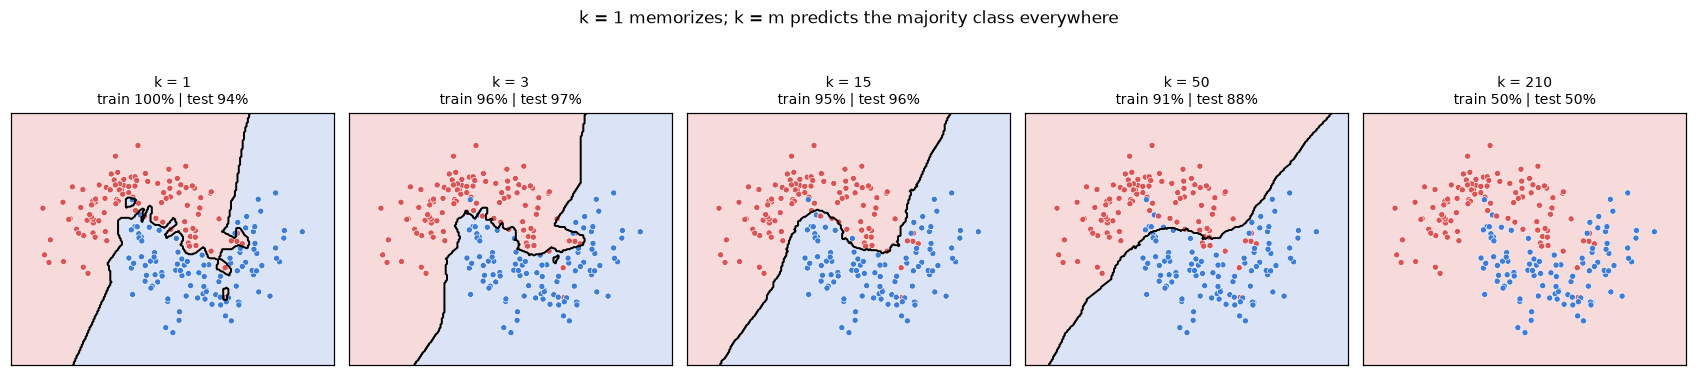

In [4]:
def plot_knn_boundary(model, X, y, ax=None, title="", pad=0.5, res=250):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.6, 4.2))
    x0, x1 = X[:, 0].min() - pad, X[:, 0].max() + pad
    y0, y1 = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x0, x1, res), np.linspace(y0, y1, res))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap=CMAP_BG, alpha=0.9)
    ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=1.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP_PTS, s=16, edgecolor="w", linewidth=0.4)
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    return ax


ks = [1, 3, 15, 50, len(ytr)]
fig, axes = plt.subplots(1, len(ks), figsize=(3.1 * len(ks), 3.2))
for ax, k in zip(axes, ks):
    m = KNN(k=k).fit(Xtr, ytr)
    plot_knn_boundary(m, Xtr, ytr, ax=ax,
                      title=f"k = {k}\ntrain {m.score(Xtr, ytr)*100:.0f}% | "
                            f"test {m.score(Xte, yte)*100:.0f}%")
plt.suptitle("k = 1 memorizes; k = m predicts the majority class everywhere", y=1.05)
plt.tight_layout(); plt.show()

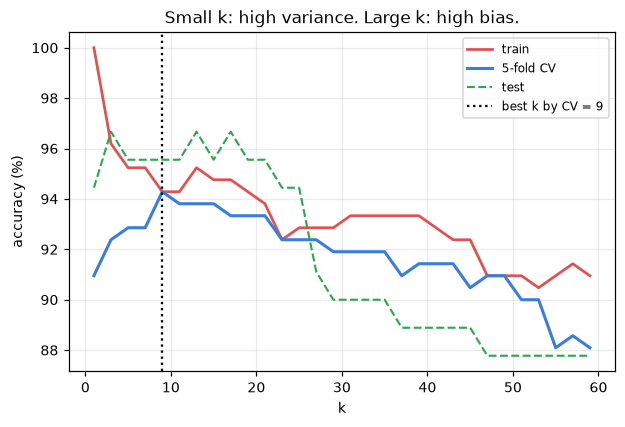

k=1  train 100%  (perfect, and meaningless)
     CV    91.0%
k=9  CV    94.3%   <- chosen without looking at the test set


In [5]:
# the classic U-shaped validation curve
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ks = np.arange(1, 61, 2)
train_acc, test_acc, cv_acc = [], [], []
for k in ks:
    m = KNN(k=k).fit(Xtr, ytr)
    train_acc.append(m.score(Xtr, ytr))
    test_acc.append(m.score(Xte, yte))
    cv_acc.append(cross_val_score(KNeighborsClassifier(n_neighbors=k), Xtr, ytr, cv=5).mean())

plt.figure(figsize=(6.4, 4))
plt.plot(ks, np.array(train_acc) * 100, color=RED, lw=1.8, label="train")
plt.plot(ks, np.array(cv_acc) * 100, color=BLUE, lw=2, label="5-fold CV")
plt.plot(ks, np.array(test_acc) * 100, color=GREEN, lw=1.4, ls="--", label="test")
best_k = ks[int(np.argmax(cv_acc))]
plt.axvline(best_k, ls=":", color="k", label=f"best k by CV = {best_k}")
plt.xlabel("k"); plt.ylabel("accuracy (%)"); plt.legend(fontsize=8)
plt.title("Small k: high variance. Large k: high bias.")
plt.show()

print(f"k=1  train {train_acc[0]*100:.0f}%  (perfect, and meaningless)")
print(f"     CV    {cv_acc[0]*100:.1f}%")
print(f"k={best_k}  CV    {max(cv_acc)*100:.1f}%   <- chosen without looking at the test set")

## 1.5 Distance weighting

With `weights="uniform"` a neighbour 10 units away counts exactly as much as one 0.1 units away. `weights="distance"` weights each vote by $1/d$, which usually helps when the data density varies, and softens the choice of `k` — a distant neighbour contributes little, so an over-large `k` does less damage.

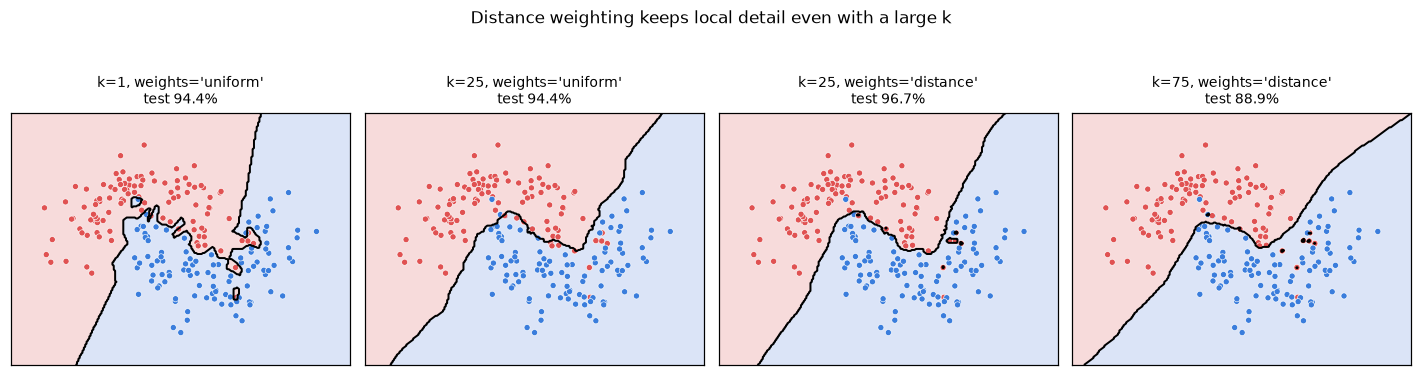

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, (k, w) in zip(axes, [(1, "uniform"), (25, "uniform"), (25, "distance"), (75, "distance")]):
    m = KNN(k=k, weights=w).fit(Xtr, ytr)
    plot_knn_boundary(m, Xtr, ytr, ax=ax,
                      title=f"k={k}, weights='{w}'\ntest {m.score(Xte, yte)*100:.1f}%")
plt.suptitle("Distance weighting keeps local detail even with a large k", y=1.05)
plt.tight_layout(); plt.show()

## 1.6 k-NN for regression, and what its predictions look like

The same algorithm, averaging instead of voting. The result is a **piecewise-constant** function with uniform weights — it can only ever output values it has seen. Two consequences follow immediately, and they apply to decision trees too:

* the prediction surface is a staircase, not a smooth curve,
* **it cannot extrapolate.** Outside the range of the training data, the nearest neighbours stop changing, so the prediction flattens into a constant.

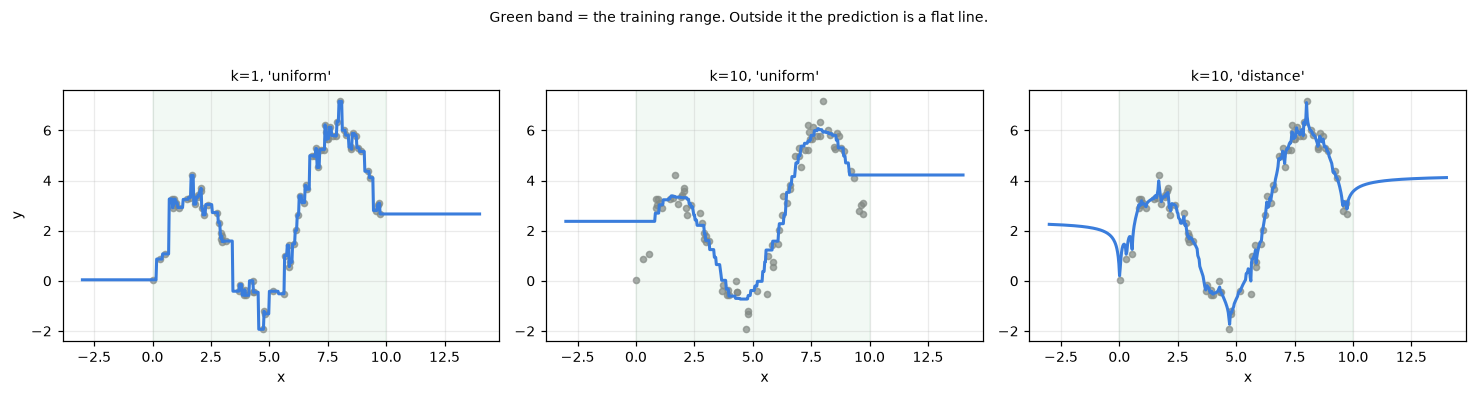

Notice the staircase inside the data and the perfectly flat lines outside it.
If your problem needs extrapolation, k-NN (and trees) are the wrong family.


In [7]:
rng = np.random.default_rng(3)
xr = np.sort(rng.uniform(0, 10, 80))
yr = np.sin(xr) * 3 + 0.4 * xr + rng.normal(0, 0.4, 80)
grid = np.linspace(-3, 14, 600).reshape(-1, 1)          # deliberately wider than the data

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4))
for ax, (k, w) in zip(axes, [(1, "uniform"), (10, "uniform"), (10, "distance")]):
    m = KNN(k=k, task="regression", weights=w).fit(xr.reshape(-1, 1), yr)
    ax.scatter(xr, yr, s=16, color=GREY, alpha=0.7)
    ax.plot(grid, m.predict(grid), color=BLUE, lw=2)
    ax.axvspan(0, 10, color=GREEN, alpha=0.06)
    ax.set_title(f"k={k}, '{w}'", fontsize=9); ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.suptitle("Green band = the training range. Outside it the prediction is a flat line.",
             y=1.04, fontsize=9)
plt.tight_layout(); plt.show()

print("Notice the staircase inside the data and the perfectly flat lines outside it.")
print("If your problem needs extrapolation, k-NN (and trees) are the wrong family.")

---

# Part 2 — What k-NN is bad at

Three weaknesses, and all three follow from the same fact: **the model is nothing but a distance function.** Anything that corrupts the distance corrupts the model.

## 2.1 Feature scale

Distance sums over features, so a feature measured in larger units contributes more — not because it matters more, but because of the unit it happens to be recorded in. Change a column from metres to millimetres and you have silently made it a thousand times more important.

This is not a small effect. It is usually the difference between a working and a useless k-NN.

In [8]:
rng = np.random.default_rng(0)
n = 400
# both features are equally informative by construction
income = rng.normal(50000, 15000, n)          # tens of thousands
age = rng.normal(40, 12, n)                   # tens
label = ((income - 50000) / 15000 + (age - 40) / 12 + rng.normal(0, 0.6, n) > 0).astype(int)

Xs = np.c_[income, age]
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, label, test_size=0.3, random_state=0)

raw = KNN(k=15).fit(Xs_tr, ys_tr)
mu, sd = Xs_tr.mean(0), Xs_tr.std(0)
scaled = KNN(k=15).fit((Xs_tr - mu) / sd, ys_tr)

print(f"feature std: income {income.std():,.0f}   age {age.std():.1f}"
      f"   ratio {income.std()/age.std():,.0f}x\n")
print(f"k-NN on raw features   : {raw.score(Xs_te, ys_te)*100:.1f}%")
print(f"k-NN on scaled features: {scaled.score((Xs_te - mu) / sd, ys_te)*100:.1f}%")

# how much does each feature actually contribute to the distance?
d_income = np.abs(Xs_tr[:50, 0, None] - Xs_tr[None, :50, 0]).mean()
d_age = np.abs(Xs_tr[:50, 1, None] - Xs_tr[None, :50, 1]).mean()
print(f"\naverage contribution to the distance:")
print(f"   income: {d_income:>10,.1f}")
print(f"   age   : {d_age:>10,.1f}   ({d_age/d_income*100:.3f}% of income's)")
print("\nThe 'age' feature is effectively invisible. The model is a one-feature model.")

feature std: income 14,927   age 12.1   ratio 1,237x

k-NN on raw features   : 69.2%
k-NN on scaled features: 84.2%

average contribution to the distance:
   income:   15,608.3
   age   :       14.7   (0.094% of income's)

The 'age' feature is effectively invisible. The model is a one-feature model.


> **Rule:** always put a `StandardScaler` in front of k-NN. Use `RobustScaler` if outliers are present, and `MinMaxScaler` if the features are bounded. For sparse or text data use cosine distance instead, and do **not** centre (it destroys sparsity).

## 2.2 The curse of dimensionality

This is the deeper problem, and the reason k-NN fades on modern datasets.

In high dimensions, **all points become roughly equidistant from each other**. The ratio between the nearest and farthest neighbour approaches 1, so "nearest" stops meaning anything. Let us measure it rather than assert it.

 dimensions    nearest   farthest   ratio far/near
----------------------------------------------------
          1      0.001      0.747          8379.82
          2      0.023      1.029            72.84
          5      0.208      1.462             7.69
         10      0.546      1.871             3.51
         50      2.161      3.529             1.64
        200      5.072      6.427             1.27
       1000     12.237     13.579             1.11


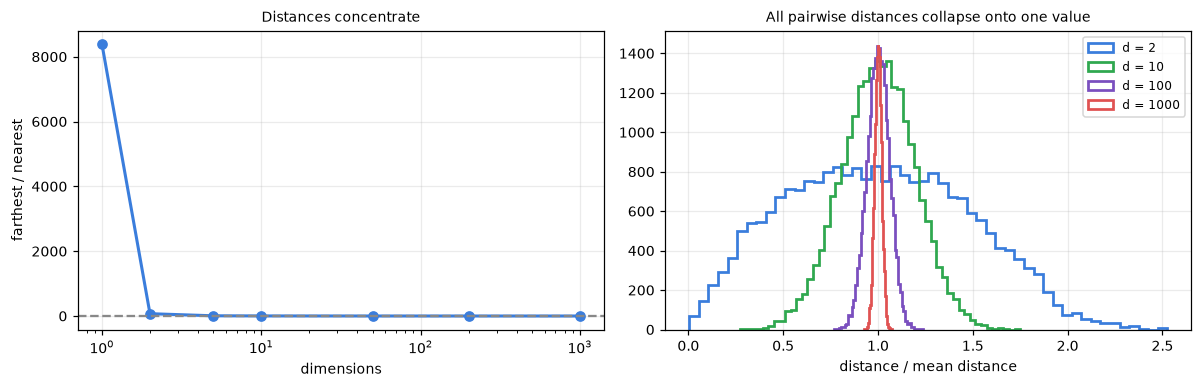


In 1000 dimensions the farthest point is only ~1.1x further than the nearest.
Ranking by distance becomes almost arbitrary - and ranking by distance is
the ENTIRE algorithm.


In [9]:
rng = np.random.default_rng(1)
dims = [1, 2, 5, 10, 50, 200, 1000]
rows = []
for d in dims:
    P = rng.uniform(0, 1, size=(500, d))
    D = np.sqrt(((P[:, None, :] - P[None, :, :]) ** 2).sum(-1))
    np.fill_diagonal(D, np.inf)
    nearest = D.min(1)
    farthest = np.where(np.isinf(D), -np.inf, D).max(1)
    rows.append((d, nearest.mean(), farthest.mean(), (farthest / nearest).mean()))

print(f"{'dimensions':>11} {'nearest':>10} {'farthest':>10} {'ratio far/near':>16}")
print("-" * 52)
for d, nr, fr, ratio in rows:
    print(f"{d:>11} {nr:>10.3f} {fr:>10.3f} {ratio:>16.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(dims, [r[3] for r in rows], "o-", color=BLUE, lw=2)
axes[0].axhline(1, ls="--", color=GREY)
axes[0].set_xscale("log"); axes[0].set_xlabel("dimensions")
axes[0].set_ylabel("farthest / nearest"); axes[0].set_title("Distances concentrate", fontsize=9)

for d, col in [(2, BLUE), (10, GREEN), (100, PURPLE), (1000, RED)]:
    P = rng.uniform(0, 1, size=(300, d))
    D = np.sqrt(((P[:150, None, :] - P[None, 150:, :]) ** 2).sum(-1)).ravel()
    axes[1].hist(D / D.mean(), bins=50, histtype="step", lw=1.8, color=col, label=f"d = {d}")
axes[1].set_xlabel("distance / mean distance"); axes[1].legend(fontsize=8)
axes[1].set_title("All pairwise distances collapse onto one value", fontsize=9)
plt.tight_layout(); plt.show()

print("\nIn 1000 dimensions the farthest point is only ~1.1x further than the nearest.")
print("Ranking by distance becomes almost arbitrary - and ranking by distance is")
print("the ENTIRE algorithm.")

There is a second, more intuitive way to see the same thing: **high-dimensional space is empty.** To capture 10% of the data volume around a query point you need a hypercube covering $0.1^{1/d}$ of each axis. In 2 dimensions that is 32% of each axis; in 100 dimensions it is **98%** — your "local" neighbourhood is nearly the whole dataset, so it is not local at all.

In [10]:
print(f"{'dimensions':>11} {'edge length for 10% of the volume':>36}")
print("-" * 50)
for d in [1, 2, 5, 10, 50, 100]:
    print(f"{d:>11} {0.1 ** (1/d)*100:>35.1f}%")

print("\nWhat to do about it:")
print("  - reduce the dimension first (PCA, feature selection, an autoencoder)")
print("  - use a metric that degrades more gracefully (L1 beats L2 in high dimensions;")
print("    cosine distance for sparse text)")
print("  - use a model that ignores irrelevant features instead of averaging over them")
print("    (trees, or a linear model with L1) - see Challenge 2")

 dimensions    edge length for 10% of the volume
--------------------------------------------------
          1                                10.0%
          2                                31.6%
          5                                63.1%
         10                                79.4%
         50                                95.5%
        100                                97.7%

What to do about it:
  - reduce the dimension first (PCA, feature selection, an autoencoder)
  - use a metric that degrades more gracefully (L1 beats L2 in high dimensions;
    cosine distance for sparse text)
  - use a model that ignores irrelevant features instead of averaging over them
    (trees, or a linear model with L1) - see Challenge 2


## 2.3 Cost, and how libraries fight it

A brute-force prediction costs $O(m \cdot n)$ per query: the whole training set, every time. Nothing is amortized, because nothing was learned.

| Structure | Idea | Where it helps |
|---|---|---|
| **KD-tree** | recursively split on axis-aligned planes | low dimension ($n \lesssim 20$) |
| **Ball tree** | nested hyperspheres | moderate dimension, non-Euclidean metrics |
| **Brute force** | one big matrix product | high dimension, or small $m$ |
| **Approximate NN** (HNSW, FAISS, Annoy) | trade exactness for speed | millions of points; how real search and recommendation systems work |

`sklearn`'s `algorithm="auto"` picks among the first three for you. Above a few hundred thousand points, or a few hundred dimensions, the exact methods all collapse to brute force and you should reach for an approximate library instead.

In [11]:
import time
from sklearn.neighbors import KNeighborsClassifier

print(f"{'train size':>11} {'dims':>6} {'brute':>9} {'kd_tree':>9} {'ball_tree':>11}")
print("-" * 50)
for m_train, d in [(2000, 2), (20000, 2), (20000, 20), (5000, 200)]:
    Xb = rng.normal(size=(m_train, d)); yb = (Xb[:, 0] > 0).astype(int)
    Xq = rng.normal(size=(500, d))
    row = [f"{m_train:>11,}", f"{d:>6}"]
    for algo in ["brute", "kd_tree", "ball_tree"]:
        knn = KNeighborsClassifier(5, algorithm=algo).fit(Xb, yb)
        t0 = time.time(); knn.predict(Xq); row.append(f"{time.time()-t0:>8.3f}s")
    print(" ".join(row))

print("\nKD-trees win in low dimension and lose badly in high dimension - in 200")
print("dimensions the tree cannot prune anything, so it is slower than brute force.")
print("That is the curse of dimensionality again, wearing a different hat.")

 train size   dims     brute   kd_tree   ball_tree
--------------------------------------------------
      2,000      2    0.028s    0.001s    0.002s
     20,000      2    0.005s    0.001s    0.003s
     20,000     20    0.005s    0.092s    0.059s
      5,000    200    0.005s    0.232s    0.177s

KD-trees win in low dimension and lose badly in high dimension - in 200
dimensions the tree cannot prune anything, so it is slower than brute force.
That is the curse of dimensionality again, wearing a different hat.


## 2.4 Honest summary of k-NN

**Good at:** low-dimensional problems with plenty of data and a natural notion of similarity; irregular, non-linear boundaries; multi-class problems with no extra work; a fast baseline in five lines; recommendation and retrieval, where "find similar items" *is* the task.

**Bad at:** high dimensions; large training sets (prediction is slow and memory is $O(mn)$); irrelevant features, which it cannot ignore; imbalanced classes, where the majority wins every vote; extrapolation; interpretability beyond "these were the neighbours".

**Practical checklist:** scale the features → choose the metric to match the data type → tune `k` and `weights` by cross-validation → reduce the dimension if $n$ is large → use an approximate index if $m$ is large.

---

# Part 3 — Naive Bayes

## 3.1 Bayes' rule as a classifier

Everything follows from one line of probability. We want $P(y \mid \mathbf{x})$ — the probability of the class given the evidence — and Bayes' rule turns it around into something we can actually estimate from data:

$$P(y \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid y)\,P(y)}{P(\mathbf{x})}$$

| Term | Name | How we get it |
|---|---|---|
| $P(y \mid \mathbf{x})$ | posterior | what we want |
| $P(\mathbf{x} \mid y)$ | likelihood | model how the features look *within* each class |
| $P(y)$ | prior | just count the classes |
| $P(\mathbf{x})$ | evidence | the same for every class, so **we can ignore it** |

Since the denominator does not depend on $y$, the prediction is simply

$$\hat{y} = \arg\max_y \; P(\mathbf{x}\mid y)\,P(y)$$

This is a **generative** model: it describes how the data in each class is *generated*, and classifies by asking which class's story explains the observation best. Logistic regression, by contrast, is **discriminative** — it models the boundary directly and never describes the data at all. We compare them in Part 5.

## 3.2 The naive assumption

There is one problem: $P(\mathbf{x}\mid y) = P(x_1, x_2, \dots, x_n \mid y)$ is a joint distribution over all features. For 20 binary features that is $2^{20}$ numbers per class, and you will never have enough data to estimate them.

The **naive** assumption cuts through this: **given the class, the features are independent.**

$$P(x_1, \dots, x_n \mid y) = \prod_{j=1}^{n} P(x_j \mid y)$$

Now we only need $n$ one-dimensional distributions per class instead of one $n$-dimensional one. The number of parameters drops from exponential to linear, and each one can be estimated from a simple count or mean.

The prediction becomes

$$\hat{y} = \arg\max_y \; \log P(y) + \sum_{j=1}^{n}\log P(x_j \mid y)$$

**Always work in log space.** Multiplying hundreds of probabilities underflows to exactly 0.0 in floating point; adding logs does not.

### The assumption is false, and it usually does not matter

In a text, "New" and "York" are obviously not independent. In medicine, blood pressure and weight are not independent. The assumption is essentially always violated.

The reason Naive Bayes survives this is worth understanding: **we do not need the probabilities to be right, only their *ranking*.** Correlated features cause the model to count the same evidence several times, which makes the estimated probabilities far too extreme — but it usually pushes them in the *correct direction*, so the arg-max is often still right. Naive Bayes is therefore a good classifier and a bad probability estimator, and we will see both halves of that in Part 6.

In [12]:
# a small worked example, entirely by hand
data = [
    # (weather, temperature, play?)
    ("sunny",    "hot",  "no"), ("sunny",    "hot",  "no"),
    ("overcast", "hot",  "yes"), ("rainy",   "mild", "yes"),
    ("rainy",    "cool", "yes"), ("rainy",   "cool", "no"),
    ("overcast", "cool", "yes"), ("sunny",   "mild", "no"),
    ("sunny",    "cool", "yes"), ("rainy",   "mild", "yes"),
    ("sunny",    "mild", "yes"), ("overcast","mild", "yes"),
    ("overcast", "hot",  "yes"), ("rainy",   "mild", "no"),
]
weather = [d[0] for d in data]; temp = [d[1] for d in data]; play = [d[2] for d in data]

query = ("sunny", "cool")
print(f"Question: will they play when it is {query[0]} and {query[1]}?\n")

for c in ["yes", "no"]:
    idx = [i for i, p in enumerate(play) if p == c]
    prior = len(idx) / len(play)
    p_w = sum(weather[i] == query[0] for i in idx) / len(idx)
    p_t = sum(temp[i] == query[1] for i in idx) / len(idx)
    print(f"class '{c}':")
    print(f"   P({c})                = {len(idx)}/{len(play)} = {prior:.3f}")
    print(f"   P({query[0]} | {c})       = {p_w:.3f}")
    print(f"   P({query[1]} | {c})        = {p_t:.3f}")
    print(f"   product              = {prior * p_w * p_t:.4f}\n")

score_yes = (play.count("yes")/len(play)) * \
    (sum(weather[i] == query[0] for i, p in enumerate(play) if p == "yes")/play.count("yes")) * \
    (sum(temp[i] == query[1] for i, p in enumerate(play) if p == "yes")/play.count("yes"))
score_no = (play.count("no")/len(play)) * \
    (sum(weather[i] == query[0] for i, p in enumerate(play) if p == "no")/play.count("no")) * \
    (sum(temp[i] == query[1] for i, p in enumerate(play) if p == "no")/play.count("no"))
print(f"normalized: P(yes|x) = {score_yes/(score_yes+score_no):.3f}, "
      f"P(no|x) = {score_no/(score_yes+score_no):.3f}")
print(f"prediction: {'yes' if score_yes > score_no else 'no'}")

Question: will they play when it is sunny and cool?

class 'yes':
   P(yes)                = 9/14 = 0.643
   P(sunny | yes)       = 0.222
   P(cool | yes)        = 0.333
   product              = 0.0476

class 'no':
   P(no)                = 5/14 = 0.357
   P(sunny | no)       = 0.600
   P(cool | no)        = 0.200
   product              = 0.0429

normalized: P(yes|x) = 0.526, P(no|x) = 0.474
prediction: yes


## 3.3 The zero-frequency problem, and smoothing

Suppose the word *"quokka"* never appears in any spam email in your training set. Then $P(\text{quokka}\mid\text{spam}) = 0$, and because the terms are **multiplied**, a single zero annihilates the entire product — no matter how spammy the other 500 words were.

The fix is **Laplace (add-$\alpha$) smoothing**: pretend you saw every value $\alpha$ extra times.

$$P(x_j = v \mid y) = \frac{\text{count}(x_j = v, y) + \alpha}{\text{count}(y) + \alpha \cdot |V_j|}$$

$\alpha = 1$ is the classic "add-one" choice; $\alpha < 1$ (Lidstone smoothing) is often better for large vocabularies. In scikit-learn this is the `alpha` parameter, and it is the main thing to tune in `MultinomialNB`.

Notice what smoothing really is: a **prior** that every event is possible. It is regularization, in the same sense as ridge — with $\alpha$ playing the role of $\lambda$.

In [13]:
counts_spam = {"free": 12, "money": 8, "meeting": 0, "quokka": 0}
n_spam = 40
vocab = 5000

print(f"{'word':<10} {'count':>6} {'no smoothing':>15} {'alpha=1':>12} {'alpha=0.01':>12}")
print("-" * 60)
for w, c in counts_spam.items():
    raw = c / n_spam
    a1 = (c + 1) / (n_spam + 1 * vocab)
    a2 = (c + 0.01) / (n_spam + 0.01 * vocab)
    print(f"{w:<10} {c:>6} {raw:>15.5f} {a1:>12.6f} {a2:>12.6f}")

print("\nWithout smoothing, 'meeting' gives probability 0 - so ANY message containing")
print("the word 'meeting' can never be classified as spam, whatever else it says.")
print("Smoothing keeps every probability strictly positive.")

word        count    no smoothing      alpha=1   alpha=0.01
------------------------------------------------------------
free           12         0.30000     0.002579     0.133444
money           8         0.20000     0.001786     0.089000
meeting         0         0.00000     0.000198     0.000111
quokka          0         0.00000     0.000198     0.000111

Without smoothing, 'meeting' gives probability 0 - so ANY message containing
the word 'meeting' can never be classified as spam, whatever else it says.
Smoothing keeps every probability strictly positive.


---

# Part 4 — The three Naive Bayes variants

The naive assumption tells us to model each feature separately, but not *how*. That choice is what distinguishes the variants:

| Variant | Assumed $P(x_j\mid y)$ | Feature type | Typical use |
|---|---|---|---|
| **GaussianNB** | Normal $\mathcal{N}(\mu_{jy}, \sigma^2_{jy})$ | continuous | general tabular data |
| **MultinomialNB** | multinomial over counts | non-negative counts | text (bag of words, TF-IDF) |
| **BernoulliNB** | Bernoulli on presence/absence | binary | short text, where presence matters more than frequency |
| ComplementNB | a variant of multinomial | counts | imbalanced text; usually beats MultinomialNB there |
| CategoricalNB | categorical | discrete categories | the weather example above |

## 4.1 Gaussian Naive Bayes from scratch

Fitting is just computing a mean and a variance per feature per class. There is no optimization at all — this is one of the very few models with a truly closed-form, single-pass fit.

In [14]:
class GaussianNaiveBayes:
    """P(x_j | y) modelled as a normal distribution. All work done in log space."""

    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        self.classes_ = np.unique(y)
        n_c, n_f = len(self.classes_), X.shape[1]
        self.theta_ = np.zeros((n_c, n_f))       # means
        self.var_ = np.zeros((n_c, n_f))         # variances
        self.log_prior_ = np.zeros(n_c)

        eps = self.var_smoothing * X.var(axis=0).max()   # avoids zero-variance features
        for i, c in enumerate(self.classes_):
            Xc = X[y == c]
            self.theta_[i] = Xc.mean(axis=0)
            self.var_[i] = Xc.var(axis=0) + eps
            self.log_prior_[i] = np.log(len(Xc) / len(y))
        return self

    def _joint_log_likelihood(self, X):
        """log P(y) + sum_j log P(x_j | y), one column per class."""
        X = np.asarray(X, dtype=float)
        out = np.zeros((len(X), len(self.classes_)))
        for i in range(len(self.classes_)):
            # log of the normal density, summed over features
            ll = -0.5 * np.sum(np.log(2 * np.pi * self.var_[i]))
            ll = ll - 0.5 * np.sum((X - self.theta_[i]) ** 2 / self.var_[i], axis=1)
            out[:, i] = self.log_prior_[i] + ll
        return out

    def predict_log_proba(self, X):
        jll = self._joint_log_likelihood(X)
        # normalize with the log-sum-exp trick, so nothing underflows
        mx = jll.max(axis=1, keepdims=True)
        log_evidence = mx + np.log(np.exp(jll - mx).sum(axis=1, keepdims=True))
        return jll - log_evidence

    def predict_proba(self, X):
        return np.exp(self.predict_log_proba(X))

    def predict(self, X):
        return self.classes_[self._joint_log_likelihood(X).argmax(axis=1)]

    def score(self, X, y):
        return float(np.mean(self.predict(X) == y))


from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(bc.data, bc.target, test_size=0.3,
                                              random_state=0, stratify=bc.target)

ours = GaussianNaiveBayes().fit(Xb_tr, yb_tr)
theirs = GaussianNB().fit(Xb_tr, yb_tr)
print(f"ours   : {ours.score(Xb_te, yb_te)*100:.2f}%")
print(f"sklearn: {theirs.score(Xb_te, yb_te)*100:.2f}%")
print(f"max difference in predicted probabilities: "
      f"{np.abs(ours.predict_proba(Xb_te) - theirs.predict_proba(Xb_te)).max():.2e}")
print(f"\nparameters learned: {ours.theta_.size + ours.var_.size + ours.log_prior_.size} "
      f"(2 numbers per feature per class, plus the priors)")
print("Fitting required a single pass over the data - no iterations at all.")

ours   : 92.40%
sklearn: 92.40%
max difference in predicted probabilities: 1.78e-15

parameters learned: 122 (2 numbers per feature per class, plus the priors)
Fitting required a single pass over the data - no iterations at all.


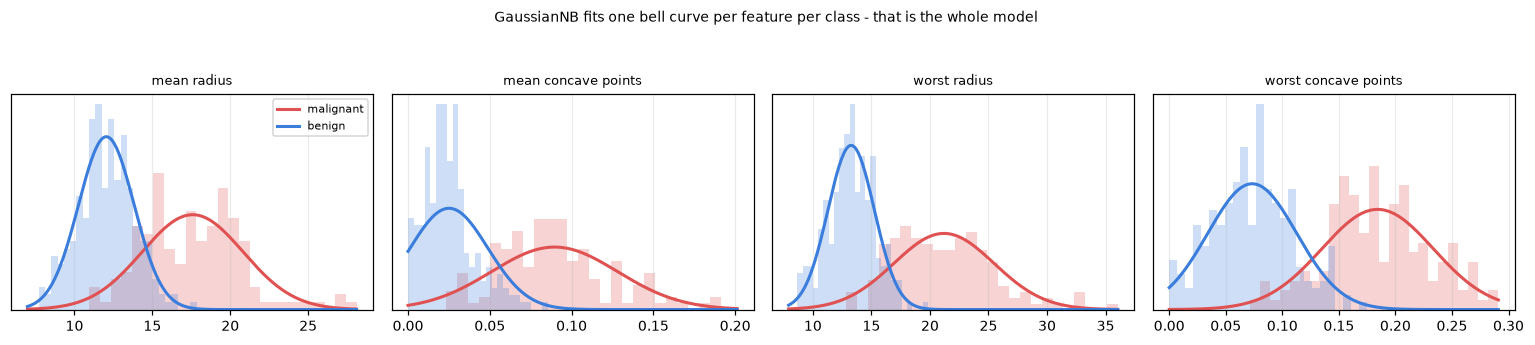

Where the two curves overlap, that feature is uninformative.
Where they separate, it carries signal. The model simply adds up the log
evidence from all 30 of these one-dimensional pictures.


In [15]:
# what the model actually believes: one Gaussian per feature per class
feat = [0, 7, 20, 27]
fig, axes = plt.subplots(1, 4, figsize=(14, 2.9))
for ax, j in zip(axes, feat):
    xs = np.linspace(bc.data[:, j].min(), bc.data[:, j].max(), 300)
    for i, (c, col) in enumerate(zip(ours.classes_, [RED, BLUE])):
        ax.hist(Xb_tr[yb_tr == c, j], bins=25, density=True, color=col, alpha=0.25)
        pdf = np.exp(-0.5 * (xs - ours.theta_[i, j]) ** 2 / ours.var_[i, j]) / \
              np.sqrt(2 * np.pi * ours.var_[i, j])
        ax.plot(xs, pdf, color=col, lw=2, label=bc.target_names[c])
    ax.set_title(bc.feature_names[j], fontsize=8.5); ax.set_yticks([])
axes[0].legend(fontsize=7)
plt.suptitle("GaussianNB fits one bell curve per feature per class - that is the whole model",
             y=1.06, fontsize=9)
plt.tight_layout(); plt.show()

print("Where the two curves overlap, that feature is uninformative.")
print("Where they separate, it carries signal. The model simply adds up the log")
print("evidence from all 30 of these one-dimensional pictures.")

## 4.2 Multinomial Naive Bayes for text

This is where Naive Bayes earned its reputation, and where it is still genuinely competitive. For a document represented as word counts:

$$P(w \mid y) = \frac{\text{count}(w, y) + \alpha}{\sum_{w'} \text{count}(w', y) + \alpha|V|}$$

Fitting is one pass of counting. Training on a million documents takes seconds, and prediction is a sparse matrix product. Nothing else is close on speed.

In [16]:
class MultinomialNaiveBayes:
    """Naive Bayes for count features (bag of words)."""

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_c, n_f = len(self.classes_), X.shape[1]
        self.log_prior_ = np.zeros(n_c)
        self.log_prob_ = np.zeros((n_c, n_f))
        for i, c in enumerate(self.classes_):
            Xc = X[y == c]
            counts = np.asarray(Xc.sum(axis=0)).ravel() + self.alpha    # smoothing
            self.log_prob_[i] = np.log(counts) - np.log(counts.sum())
            self.log_prior_[i] = np.log(Xc.shape[0] / X.shape[0])
        return self

    def _jll(self, X):
        return np.asarray(X @ self.log_prob_.T) + self.log_prior_       # one matrix product

    def predict(self, X):
        return self.classes_[self._jll(X).argmax(axis=1)]

    def predict_proba(self, X):
        jll = self._jll(X)
        mx = jll.max(axis=1, keepdims=True)
        e = np.exp(jll - mx)
        return e / e.sum(axis=1, keepdims=True)

    def score(self, X, y):
        return float(np.mean(self.predict(X) == y))


def make_text_data(n=4000, vocab=2000, doc_len=30, seed=0):
    """Synthetic two-topic corpus: each class prefers its own words, but most of the
    vocabulary is shared, so the two topics are genuinely hard to tell apart."""
    rng = np.random.default_rng(seed)
    y = (rng.random(n) > 0.5).astype(int)
    p0 = rng.dirichlet(np.ones(vocab) * 0.3)
    p1 = rng.dirichlet(np.ones(vocab) * 0.3)
    mix = 0.15                                     # only 15% class-specific: a hard corpus
    shared = rng.dirichlet(np.ones(vocab) * 0.3)
    P = [mix * p0 + (1 - mix) * shared, mix * p1 + (1 - mix) * shared]
    X = np.zeros((n, vocab), dtype=np.float64)
    for i in range(n):
        words = rng.choice(vocab, size=doc_len, p=P[y[i]])
        idx, cnt = np.unique(words, return_counts=True)
        X[i, idx] = cnt
    return X, y


Xt, yt = make_text_data()
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(Xt, yt, test_size=0.3, random_state=0)
print(f"documents {Xt.shape[0]}, vocabulary {Xt.shape[1]}, "
      f"{100*(Xt == 0).mean():.1f}% zeros\n")

from sklearn.naive_bayes import MultinomialNB
t0 = time.time(); mine = MultinomialNaiveBayes(alpha=1.0).fit(Xt_tr, yt_tr); t_mine = time.time()-t0
t0 = time.time(); skl = MultinomialNB(alpha=1.0).fit(Xt_tr, yt_tr); t_skl = time.time()-t0
print(f"ours   : {mine.score(Xt_te, yt_te)*100:.2f}%  (fit in {t_mine*1000:.0f} ms)")
print(f"sklearn: {skl.score(Xt_te, yt_te)*100:.2f}%  (fit in {t_skl*1000:.0f} ms)")

print(f"\n{'alpha':>10} {'test accuracy':>15}")
print("-" * 28)
for a in [1e-10, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    print(f"{a:>10} {MultinomialNaiveBayes(alpha=a).fit(Xt_tr, yt_tr).score(Xt_te, yt_te)*100:>14.2f}%")
print("\nalpha is a regularizer, and the curve has the shape you now expect: flat on")
print("the left, then a clear collapse once alpha is large enough to wash out the")
print("differences between words. Tune it by cross-validation - and note that the")
print("useful range here is far below the default of 1.0, which is typical for text.")

documents 4000, vocabulary 2000, 98.5% zeros

ours   : 88.25%  (fit in 7 ms)
sklearn: 88.25%  (fit in 3 ms)

     alpha   test accuracy
----------------------------
     1e-10          88.58%
     0.001          88.58%
      0.01          88.92%
       0.1          89.08%
       1.0          88.25%
      10.0          84.92%
     100.0          76.42%

alpha is a regularizer, and the curve has the shape you now expect: flat on
the left, then a clear collapse once alpha is large enough to wash out the
differences between words. Tune it by cross-validation - and note that the
useful range here is far below the default of 1.0, which is typical for text.


---

# Part 5 — Generative vs discriminative

Naive Bayes and logistic regression make a famous pair. For binary features, they even have the *same functional form* — both end up computing a linear function of the features and thresholding it. The difference is entirely in **how the coefficients are chosen**:

| | Naive Bayes (generative) | Logistic regression (discriminative) |
|---|---|---|
| Models | $P(\mathbf{x}\mid y)$ and $P(y)$ | $P(y \mid \mathbf{x})$ directly |
| Fitting | counting; closed form, one pass | iterative optimization |
| Assumptions | strong (feature independence) | weak (a linear log-odds boundary) |
| With little data | **better** — the assumption acts as a strong prior | overfits |
| With lots of data | plateaus below its rival, because the assumption is wrong | **better** — converges to the best linear boundary |
| Correlated features | double-counts evidence; probabilities become extreme | handles them properly |
| Speed | extremely fast | fast |

The classic result (Ng & Jordan, 2001) is that **Naive Bayes converges faster to its own — higher — asymptotic error**. But whether it ever loses depends entirely on one thing: **is its assumption true for your data?** Let's test both regimes rather than assert either.

assumption TRUE:
 train size   Naive Bayes   Logistic
         20         72.1%      88.9%
         40         90.6%      94.4%
         80         96.1%      96.5%
        200         98.0%      97.5%   <- NB ahead
        600         98.5%      97.7%   <- NB ahead
       2000         98.7%      98.0%   <- NB ahead
       5600         98.7%      98.3%   <- NB ahead

assumption FALSE:
 train size   Naive Bayes   Logistic
         20         82.1%      84.1%
         40         84.5%      88.2%
         80         88.6%      91.6%
        200         90.7%      93.3%
        600         91.1%      94.2%
       2000         91.3%      94.7%
       5600         91.2%      95.0%



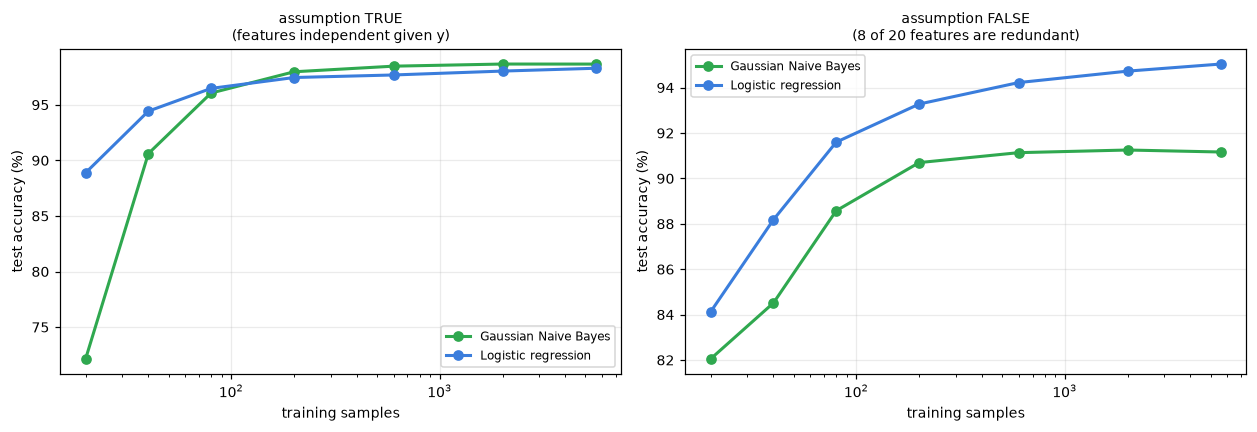

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification


def independent_data(n=8000, n_features=100, n_informative=40, delta=0.35, seed=0):
    """The naive assumption is TRUE here: features are independent given the class."""
    rng = np.random.default_rng(seed)
    y = (rng.random(n) > 0.5).astype(int)
    X = rng.normal(size=(n, n_features))
    X[:, :n_informative] += (y[:, None] * 2 - 1) * delta
    return X, y


def correlated_data(n=8000, seed=0):
    """The naive assumption is FALSE: many features are linear combinations of others."""
    return make_classification(n_samples=n, n_features=20, n_informative=8,
                               n_redundant=8, class_sep=1.0, random_state=seed)


def learning_curves(X, y, sizes, reps=10, seed=0):
    Xtr_full, Xte_, ytr_full, yte_ = train_test_split(X, y, test_size=0.3, random_state=0)
    rng = np.random.default_rng(seed)
    nb_c, lr_c = [], []
    for m_sub in sizes:
        nb_s, lr_s = [], []
        for _ in range(reps):
            idx = rng.choice(len(ytr_full), m_sub, replace=False)
            Xs_, ys_ = Xtr_full[idx], ytr_full[idx]
            if len(np.unique(ys_)) < 2:
                continue
            nb_s.append(GaussianNB().fit(Xs_, ys_).score(Xte_, yte_))
            lr_s.append(make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
                        .fit(Xs_, ys_).score(Xte_, yte_))
        nb_c.append(np.mean(nb_s)); lr_c.append(np.mean(lr_s))
    return np.array(nb_c), np.array(lr_c)


sizes = [20, 40, 80, 200, 600, 2000, 5600]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
for ax, (title, data) in zip(axes, [
        ("assumption TRUE\n(features independent given y)", independent_data()),
        ("assumption FALSE\n(8 of 20 features are redundant)", correlated_data())]):
    nb_c, lr_c = learning_curves(*data, sizes)
    ax.plot(sizes, nb_c * 100, "o-", color=GREEN, lw=2, label="Gaussian Naive Bayes")
    ax.plot(sizes, lr_c * 100, "o-", color=BLUE, lw=2, label="Logistic regression")
    ax.set_xscale("log"); ax.set_xlabel("training samples"); ax.set_ylabel("test accuracy (%)")
    ax.set_title(title, fontsize=9); ax.legend(fontsize=8)
    print(f"{title.splitlines()[0]}:")
    print(f"{'train size':>11} {'Naive Bayes':>13} {'Logistic':>10}")
    for s_, a, b in zip(sizes, nb_c, lr_c):
        print(f"{s_:>11} {a*100:>12.1f}% {b*100:>9.1f}%"
              f"{'   <- NB ahead' if a > b else ''}")
    print()
plt.tight_layout(); plt.show()

### Reading the two panels

**Left (assumption true).** Naive Bayes is not merely competitive — it is the **correct generative model** for this data, so no method can beat it asymptotically, and it does not. Logistic regression has to estimate 100 free coefficients and never quite catches up.

**Right (assumption false).** Naive Bayes climbs quickly and then **plateaus below** logistic regression. The redundant features are counted as independent evidence, which caps how good the model can get no matter how much data you give it. That plateau is the price of the assumption.

**One honest caveat about the classic story.** The textbook claim that "Naive Bayes wins in the small-data regime" was measured against *unregularized* logistic regression. Modern implementations regularize by default (scikit-learn applies L2 unless you ask it not to), and regularization is itself a way of injecting a prior — so it buys logistic regression much of the same small-sample robustness. The gap at the left edge of these plots is far smaller than the 2001 paper would suggest.

**The practical takeaway.** Both are cheap. Fit both, look at the learning curve, and let the data tell you which assumption fits.

---

# Part 6 — Six challenge problems

## Challenge 1 — k-NN drowned by irrelevant features

**The task.** Two genuinely informative features, plus a growing number of pure-noise columns. Nothing about the problem changes — we are only adding columns that contain no information.

k-NN has no way to ignore them: every feature contributes equally to the distance, so noise steadily dilutes the signal until the neighbours are effectively random.

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier

rng = np.random.default_rng(0)
n = 1200
X_sig, y_n = make_moons(n_samples=n, noise=0.2, random_state=0)

print(f"{'noise features':>15} {'k-NN':>8} {'logistic':>10} {'tree':>8} {'GaussianNB':>12}")
print("-" * 58)
knn_curve, n_noise_list = [], [0, 5, 20, 50, 200]
for n_noise in n_noise_list:
    Xn = np.hstack([X_sig, rng.normal(size=(n, n_noise))]) if n_noise else X_sig
    Xa, Xb_, ya, yb_ = train_test_split(Xn, y_n, test_size=0.3, random_state=0, stratify=y_n)
    row = [f"{n_noise:>15}"]
    for mdl in [KNeighborsClassifier(15), LogisticRegression(max_iter=2000),
                DecisionTreeClassifier(max_depth=6, random_state=0), GaussianNB()]:
        s = make_pipeline(StandardScaler(), mdl).fit(Xa, ya).score(Xb_, yb_)
        row.append(f"{s*100:>9.1f}%")
    knn_curve.append(float(row[1].strip().rstrip('%')))
    print(" ".join(row))

print("\nDIAGNOSIS: k-NN degrades fastest, because it AVERAGES over all features.")
print("The tree and the linear model can put (near) zero weight on a useless column;")
print("a distance cannot.")

 noise features     k-NN   logistic     tree   GaussianNB
----------------------------------------------------------
              0      98.6%      88.3%      96.9%      87.8%
              5      90.6%      88.9%      96.9%      88.1%
             20      83.3%      88.3%      95.8%      87.5%
             50      79.2%      86.1%      95.3%      88.1%
            200      63.9%      82.8%      94.4%      86.1%

DIAGNOSIS: k-NN degrades fastest, because it AVERAGES over all features.
The tree and the linear model can put (near) zero weight on a useless column;
a distance cannot.


**The fix.** Give k-NN a smaller, cleaner space to measure distances in — by selecting features, or by projecting.

In [19]:
n_noise = 200
Xn = np.hstack([X_sig, rng.normal(size=(n, n_noise))])
Xa, Xb_, ya, yb_ = train_test_split(Xn, y_n, test_size=0.3, random_state=0, stratify=y_n)

print(f"{'approach':<44} {'test accuracy':>14}")
print("-" * 60)
for name, pipe in [
    ("k-NN on all 202 features",
     make_pipeline(StandardScaler(), KNeighborsClassifier(15))),
    ("k-NN + SelectKBest(f_classif, k=2)",
     make_pipeline(StandardScaler(), SelectKBest(f_classif, k=2), KNeighborsClassifier(15))),
    ("k-NN + SelectKBest(k=10)",
     make_pipeline(StandardScaler(), SelectKBest(f_classif, k=10), KNeighborsClassifier(15))),
    ("k-NN + PCA(10 components)",
     make_pipeline(StandardScaler(), PCA(n_components=10, random_state=0), KNeighborsClassifier(15))),
    ("k-NN with Manhattan (L1) distance",
     make_pipeline(StandardScaler(), KNeighborsClassifier(15, p=1))),
]:
    pipe.fit(Xa, ya)
    print(f"{name:<44} {pipe.score(Xb_, yb_)*100:>13.1f}%")

print("\nSelectKBest recovers nearly all the lost accuracy - and note that k=2 beats")
print("k=10, because every extra column is pure noise.")
print("\nTwo results worth reading carefully:")
print("  - PCA makes things WORSE. PCA is unsupervised: it keeps the directions of")
print("    highest VARIANCE, and after standardizing, 200 noise columns have exactly")
print("    as much variance as the 2 useful ones. Variance is not relevance.")
print("  - L1 distance helps only marginally here. It degrades more gracefully than")
print("    L2 in high dimensions, but it cannot manufacture signal that is not there.")
print("    Removing the bad features is the real fix; the metric is a second-order knob.")
print("\nCAUTION: SelectKBest uses the TARGET, so it must live inside the Pipeline")
print("(as it does here) or it leaks - exactly the rule from the regression notebook.")

approach                                      test accuracy
------------------------------------------------------------
k-NN on all 202 features                              71.7%
k-NN + SelectKBest(f_classif, k=2)                    98.6%
k-NN + SelectKBest(k=10)                              86.4%
k-NN + PCA(10 components)                             63.1%
k-NN with Manhattan (L1) distance                     72.2%

SelectKBest recovers nearly all the lost accuracy - and note that k=2 beats
k=10, because every extra column is pure noise.

Two results worth reading carefully:
  - PCA makes things WORSE. PCA is unsupervised: it keeps the directions of
    highest VARIANCE, and after standardizing, 200 noise columns have exactly
    as much variance as the 2 useful ones. Variance is not relevance.
  - L1 distance helps only marginally here. It degrades more gracefully than
    L2 in high dimensions, but it cannot manufacture signal that is not there.
    Removing the bad features is the

## Challenge 2 — k-NN on imbalanced data

**The task.** 5% positives. Majority voting among neighbours is structurally biased towards the majority class: even inside a positive region, a large `k` will often collect more negatives than positives.

In [20]:
from sklearn.metrics import average_precision_score, recall_score, precision_score

Xi, yi = make_classification(n_samples=4000, n_features=10, n_informative=5,
                             weights=[0.95, 0.05], flip_y=0.01, random_state=3)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, yi, test_size=0.3, random_state=0, stratify=yi)
print(f"positives: {yi_tr.mean()*100:.1f}%\n")

def knn_report(name, pipe, thr=0.5):
    pipe.fit(Xi_tr, yi_tr)
    p = pipe.predict_proba(Xi_te)[:, 1]
    pred = (p >= thr).astype(int)
    print(f"{name:<40} {(pred == yi_te).mean()*100:>8.1f}% "
          f"{recall_score(yi_te, pred):>8.3f} {precision_score(yi_te, pred, zero_division=0):>10.3f} "
          f"{average_precision_score(yi_te, p):>8.3f}")
    return p

print(f"{'setup':<40} {'accuracy':>8} {'recall':>8} {'precision':>10} {'AP':>8}")
print("-" * 78)
p_big = knn_report("k=25, uniform", make_pipeline(StandardScaler(), KNeighborsClassifier(25)))
knn_report("k=5, uniform", make_pipeline(StandardScaler(), KNeighborsClassifier(5)))
knn_report("k=25, distance-weighted",
           make_pipeline(StandardScaler(), KNeighborsClassifier(25, weights="distance")))
knn_report("k=25, threshold = 0.15",
           make_pipeline(StandardScaler(), KNeighborsClassifier(25)), thr=0.15)

print("\nDIAGNOSIS: with k=25 and 5% positives, a query in a positive region needs 13")
print("of its 25 neighbours to be positive - a high bar when they are rare.")
print("\nFIXES, in order of preference:")
print("  1. lower the decision threshold on predict_proba (the fraction of positive")
print("     neighbours is already a usable score - only the 0.5 cutoff was wrong)")
print("  2. use distance weighting, so a nearby positive outvotes distant negatives")
print("  3. use a smaller k")
print("  4. resample - but note this changes the density k-NN depends on, so it is")
print("     less benign here than for other models")

positives: 5.5%

setup                                    accuracy   recall  precision       AP
------------------------------------------------------------------------------
k=25, uniform                                95.9%    0.258      1.000    0.681
k=5, uniform                                 96.9%    0.485      0.914    0.598
k=25, distance-weighted                      95.8%    0.258      0.944    0.704
k=25, threshold = 0.15                       96.6%    0.667      0.698    0.681

DIAGNOSIS: with k=25 and 5% positives, a query in a positive region needs 13
of its 25 neighbours to be positive - a high bar when they are rare.

FIXES, in order of preference:
  1. lower the decision threshold on predict_proba (the fraction of positive
     neighbours is already a usable score - only the 0.5 cutoff was wrong)
  2. use distance weighting, so a nearby positive outvotes distant negatives
  3. use a smaller k
  4. resample - but note this changes the density k-NN depends on, so it is


## Challenge 3 — Naive Bayes meets correlated features

**The task.** The independence assumption, violated on purpose. We duplicate one informative feature several times — adding **no new information at all** — and watch what happens.

This is the sharpest demonstration of what "naive" costs you: the model treats each copy as independent confirmation, so it counts the same evidence over and over.

In [21]:
rng = np.random.default_rng(7)
n = 1500
f1 = rng.normal(size=n)
f2 = rng.normal(size=n)
yc = (0.9 * f1 + 0.9 * f2 + rng.normal(0, 0.7, n) > 0).astype(int)

print(f"{'copies of f1':>13} {'NB accuracy':>13} {'NB mean confidence':>21} {'logistic':>10}")
print("-" * 62)
for n_copy in [1, 2, 5, 15, 40]:
    cols = [f1 + rng.normal(0, 0.01, n) for _ in range(n_copy)] + [f2]
    Xc = np.column_stack(cols)
    Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, random_state=0)
    nb = GaussianNB().fit(Xc_tr, yc_tr)
    lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(Xc_tr, yc_tr)
    conf = nb.predict_proba(Xc_te).max(1).mean()
    print(f"{n_copy:>13} {nb.score(Xc_te, yc_te)*100:>12.1f}% {conf:>20.4f} "
          f"{lr.score(Xc_te, yc_te)*100:>9.1f}%")

print("\nDIAGNOSIS: accuracy drifts down a little, but look at the CONFIDENCE column.")
print("With 40 near-identical copies the model is ~100% certain of every prediction,")
print("including the wrong ones. It multiplied the same piece of evidence 40 times.")
print("\nFIXES: drop correlated columns (check a correlation matrix or VIF), or")
print("decorrelate with PCA, or - if you need trustworthy probabilities - calibrate.")

 copies of f1   NB accuracy    NB mean confidence   logistic
--------------------------------------------------------------
            1         83.1%               0.7567      84.0%
            2         83.1%               0.8188      84.2%
            5         77.1%               0.8996      84.2%
           15         74.4%               0.9607      84.2%
           40         73.8%               0.9834      84.2%

DIAGNOSIS: accuracy drifts down a little, but look at the CONFIDENCE column.
With 40 near-identical copies the model is ~100% certain of every prediction,
including the wrong ones. It multiplied the same piece of evidence 40 times.

FIXES: drop correlated columns (check a correlation matrix or VIF), or
decorrelate with PCA, or - if you need trustworthy probabilities - calibrate.


## Challenge 4 — Naive Bayes probabilities are not probabilities

**The task.** Even with well-behaved features, NB's posterior is systematically pushed towards 0 and 1. Accuracy can be fine while the numbers themselves are unusable for any decision that depends on their value — expected cost, ranking thresholds, downstream Bayesian reasoning.

model                         accuracy      AUC   Brier score
--------------------------------------------------------------
GaussianNB                       92.4%   0.9768        0.0760
Logistic regression              95.9%   0.9956        0.0265
GaussianNB + isotonic            91.8%   0.9629        0.0614


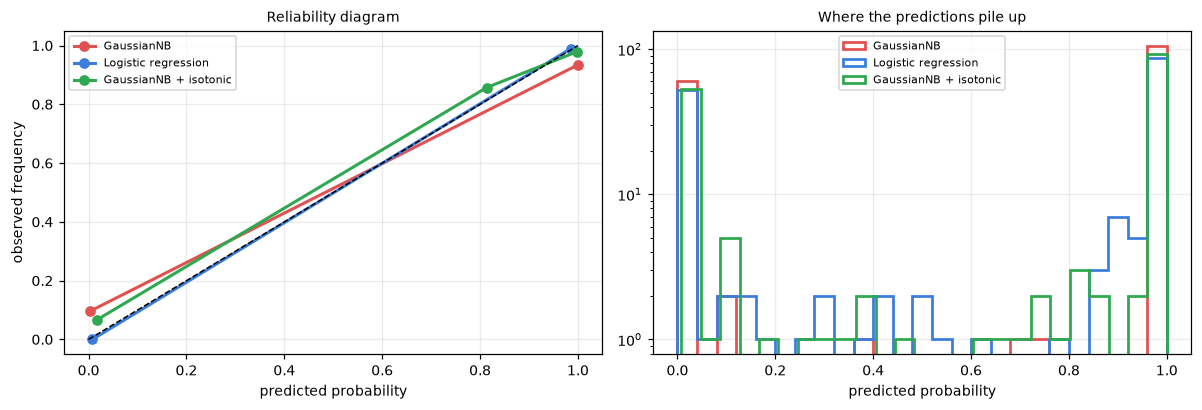


DIAGNOSIS: NB's histogram is two spikes at 0 and 1 with almost nothing between.
Its AUC is fine - the RANKING is good - but the Brier score is poor because
the values are wrong. Remember the distinction:
   good ranking  -> use it to classify, or to sort
   good calibration -> use it in a cost calculation
Isotonic or sigmoid calibration fixes the second without harming the first.


In [22]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, roc_auc_score

nb = GaussianNB().fit(Xb_tr, yb_tr)
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xb_tr, yb_tr)
nb_cal = CalibratedClassifierCV(GaussianNB(), cv=5, method="isotonic").fit(Xb_tr, yb_tr)

def calib_curve(y, p, n_bins=8):
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
    xs, ys = [], []
    for b in range(n_bins):
        m = idx == b
        if m.sum() >= 5:
            xs.append(p[m].mean()); ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

print(f"{'model':<28} {'accuracy':>9} {'AUC':>8} {'Brier score':>13}")
print("-" * 62)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name, mdl, col in [("GaussianNB", nb, RED), ("Logistic regression", lr, BLUE),
                       ("GaussianNB + isotonic", nb_cal, GREEN)]:
    p = mdl.predict_proba(Xb_te)[:, 1]
    print(f"{name:<28} {mdl.score(Xb_te, yb_te)*100:>8.1f}% "
          f"{roc_auc_score(yb_te, p):>8.4f} {brier_score_loss(yb_te, p):>13.4f}")
    xs, ys = calib_curve(yb_te, p)
    axes[0].plot(xs, ys, "o-", color=col, lw=2, label=name)
    axes[1].hist(p, bins=25, histtype="step", lw=1.8, color=col, label=name)

axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("predicted probability"); axes[0].set_ylabel("observed frequency")
axes[0].set_title("Reliability diagram", fontsize=9); axes[0].legend(fontsize=7)
axes[1].set_xlabel("predicted probability"); axes[1].set_yscale("log")
axes[1].set_title("Where the predictions pile up", fontsize=9); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

print("\nDIAGNOSIS: NB's histogram is two spikes at 0 and 1 with almost nothing between.")
print("Its AUC is fine - the RANKING is good - but the Brier score is poor because")
print("the values are wrong. Remember the distinction:")
print("   good ranking  -> use it to classify, or to sort")
print("   good calibration -> use it in a cost calculation")
print("Isotonic or sigmoid calibration fixes the second without harming the first.")

## Challenge 5 — Text classification: the right tool for the shape of the data

**The task.** Sparse, high-dimensional bag-of-words. This is simultaneously k-NN's worst case (the curse of dimensionality) and Naive Bayes' best case (the independence assumption is wrong but harmless, and counting is fast).

In [23]:
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(Xt, yt, test_size=0.3, random_state=0)

print(f"{'model':<44} {'fit':>8} {'predict':>9} {'accuracy':>10}")
print("-" * 74)
for name, mdl in [
    ("MultinomialNB (alpha=0.1)", MultinomialNB(alpha=0.1)),
    ("GaussianNB  (wrong distribution for counts)", GaussianNB()),
    ("k-NN, euclidean, k=15", KNeighborsClassifier(15)),
    ("k-NN, cosine, k=15", KNeighborsClassifier(15, metric="cosine")),
    ("Logistic regression", LogisticRegression(max_iter=2000)),
]:
    t0 = time.time(); mdl.fit(Xt_tr, yt_tr); t_fit = time.time() - t0
    t0 = time.time(); acc = mdl.score(Xt_te, yt_te); t_pred = time.time() - t0
    print(f"{name:<44} {t_fit:>7.2f}s {t_pred:>8.2f}s {acc*100:>9.1f}%")

print("\nDIAGNOSIS: three lessons in one table.")
print("  1. Euclidean k-NN struggles: 2000 dimensions, distances have concentrated.")
print("  2. Switching to COSINE distance helps a lot - for text, direction carries the")
print("     meaning and document length is a nuisance.")
print("  3. MultinomialNB matches or beats everything at a fraction of the cost,")
print("     because its generative story (words drawn from a per-class distribution)")
print("     actually fits how the data was made.")
print("  4. GaussianNB does poorly: modelling integer counts with a bell curve is the")
print("     wrong likelihood. Choosing the right VARIANT matters as much as the model.")

model                                             fit   predict   accuracy
--------------------------------------------------------------------------
MultinomialNB (alpha=0.1)                       0.01s     0.00s      89.1%
GaussianNB  (wrong distribution for counts)     0.01s     0.01s      82.9%
k-NN, euclidean, k=15                           0.00s     0.04s      56.8%
k-NN, cosine, k=15                              0.00s     0.07s      57.2%
Logistic regression                             0.04s     0.00s      80.8%

DIAGNOSIS: three lessons in one table.
  1. Euclidean k-NN struggles: 2000 dimensions, distances have concentrated.
  2. Switching to COSINE distance helps a lot - for text, direction carries the
     meaning and document length is a nuisance.
  3. MultinomialNB matches or beats everything at a fraction of the cost,
     because its generative story (words drawn from a per-class distribution)
     actually fits how the data was made.
  4. GaussianNB does poorly: modelli

## Challenge 6 — Choosing `k` honestly

**The task.** A subtle one. It is tempting to pick `k` by looking at test accuracy, or to evaluate 1-NN on its own training set. Both produce numbers that are pure fiction.

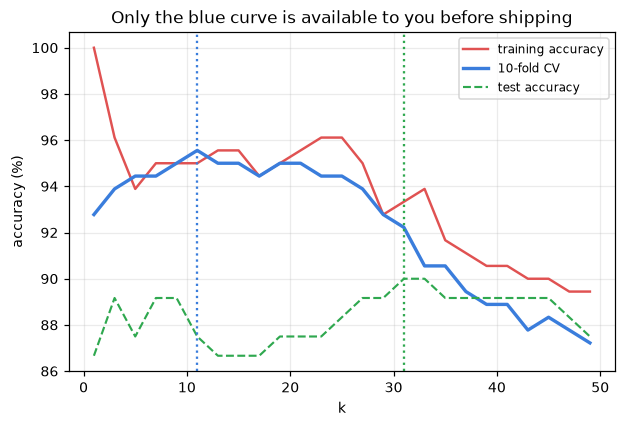

training accuracy at k=1 : 100.0%   <- meaningless
   (with k=1 every training point is its own nearest neighbour, so the
    training score is 100% by construction, whatever the data looks like)

k chosen by CV        : 11   -> test accuracy 87.5%
k chosen by peeking   : 31   -> test accuracy 90.0%

The second number is not a real result. If you choose a hyperparameter using
the test set, the test set has become a training set and you no longer have
an honest estimate of anything.


In [24]:
Xm, ym = make_moons(n_samples=300, noise=0.3, random_state=5)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.4, random_state=0)

ks = np.arange(1, 51, 2)
tr, cv, te = [], [], []
for k in ks:
    p = make_pipeline(StandardScaler(), KNeighborsClassifier(k))
    cv.append(cross_val_score(p, Xm_tr, ym_tr, cv=10).mean())
    p.fit(Xm_tr, ym_tr)
    tr.append(p.score(Xm_tr, ym_tr)); te.append(p.score(Xm_te, ym_te))

k_cv = ks[int(np.argmax(cv))]
k_te = ks[int(np.argmax(te))]

plt.figure(figsize=(6.4, 4))
plt.plot(ks, np.array(tr) * 100, color=RED, lw=1.6, label="training accuracy")
plt.plot(ks, np.array(cv) * 100, color=BLUE, lw=2.2, label="10-fold CV")
plt.plot(ks, np.array(te) * 100, color=GREEN, lw=1.4, ls="--", label="test accuracy")
plt.axvline(k_cv, ls=":", color=BLUE); plt.axvline(k_te, ls=":", color=GREEN)
plt.xlabel("k"); plt.ylabel("accuracy (%)"); plt.legend(fontsize=8)
plt.title("Only the blue curve is available to you before shipping")
plt.show()

print(f"training accuracy at k=1 : {tr[0]*100:.1f}%   <- meaningless")
print("   (with k=1 every training point is its own nearest neighbour, so the")
print("    training score is 100% by construction, whatever the data looks like)")
print(f"\nk chosen by CV        : {k_cv}   -> test accuracy {te[list(ks).index(k_cv)]*100:.1f}%")
print(f"k chosen by peeking   : {k_te}   -> test accuracy {max(te)*100:.1f}%")
print("\nThe second number is not a real result. If you choose a hyperparameter using")
print("the test set, the test set has become a training set and you no longer have")
print("an honest estimate of anything.")

---

# Part 7 — Summary

| Concept | k-NN | Naive Bayes |
|---|---|---|
| Type | instance-based, lazy, **discriminative-ish** (non-parametric) | model-based, eager, **generative** |
| Training cost | none (just stores the data) | one pass of counting |
| Prediction cost | $O(mn)$ per query — expensive | $O(n)$ per query — trivial |
| Key hyperparameter | `k`, `weights`, the metric | `alpha` (smoothing), and the variant |
| Needs scaling | **yes, always** | no (each feature is modelled separately) |
| Handles irrelevant features | badly | reasonably |
| Handles correlated features | reasonably | badly (double-counts evidence) |
| Probabilities | crude (fraction of neighbours) | well ranked, badly calibrated |
| Breaks down when | dimension is high, data is large | features are strongly dependent |
| Shines when | low dimension, plenty of data, irregular boundary | text, very high dimension, little data, speed matters |

### Five things worth remembering

1. **k-NN is a distance function wearing a model's clothes.** Scale your features, choose the metric to match the data type, and remember that it cannot ignore a useless column.
2. **The curse of dimensionality is not a metaphor.** We measured it: past a few dozen dimensions, "nearest" stops carrying information.
3. **Naive Bayes' assumption is false and it still works** — because classification needs the ranking to be right, not the probabilities.
4. **Pick the right NB variant for the data type.** Gaussian for continuous, Multinomial for counts, Bernoulli for presence/absence. Using the wrong likelihood costs more than any hyperparameter.
5. **Both are excellent baselines.** They take seconds to fit and tell you immediately whether a problem has signal in it. Run them before anything expensive.

### Where this connects

* The **generative vs discriminative** distinction runs through all of machine learning: NB vs logistic regression here, and later autoregressive language models vs classifiers.
* **Distance-based reasoning** returns as kernels in SVMs, as embeddings in NLP, and as vector search in retrieval systems — a modern semantic search engine is, structurally, k-NN over learned embeddings.
* **Smoothing** is regularization, and the same idea appears as a prior in every Bayesian method.

---

## Exercises

**1. Implement your own metric.** Add cosine distance to the `KNN` class and compare it with Euclidean on the text data of Challenge 5. Explain the gap.

**2. The 1-NN Voronoi diagram.** For 15 random points in 2-D, plot the 1-NN decision regions. Confirm visually that they are the Voronoi cells of the training points.

**3. Weighted voting by hand.** Take one misclassified test point from Part 1, print its `k` neighbours with their distances and labels, and work out by hand why uniform and distance weighting disagree.

**4. Bernoulli vs Multinomial.** Binarize the text data (presence/absence instead of counts) and compare `BernoulliNB` with `MultinomialNB`. For which document lengths does each win, and why?

**5. Derive the linear form.** Show that for binary features, Naive Bayes' decision rule can be written as $\mathbf{w}^\top\mathbf{x}+b > 0$, and give $\mathbf{w}$ and $b$ in terms of the conditional probabilities. This is why it is often compared directly with logistic regression.

**6. Break the crossover.** In Part 5 the two learning curves crossed. Construct a dataset where Naive Bayes *never* catches up (hint: make the features strongly dependent), and one where it always wins.

**7. k-NN as a recommender.** Build a small user–item rating matrix, and use cosine k-NN over users to predict missing ratings. This is collaborative filtering, and it is the same algorithm.

**8. Condensed nearest neighbour.** Implement a rule that deletes training points which are not needed to preserve the 1-NN decision boundary. How much of the data can you remove before accuracy drops?

---

## Resources

### Theory

| Link | Why |
|---|---|
| [An Introduction to Statistical Learning](https://www.statlearning.com/) | k-NN in chapter 2 (as the introduction to bias-variance) and chapter 4. Free PDF. |
| [The Elements of Statistical Learning](https://hastie.su.domains/ElemStatLearn/) | Chapter 13 on prototype and nearest-neighbour methods; section 6.6 on the curse of dimensionality. |
| [On Discriminative vs. Generative Classifiers](https://ai.stanford.edu/~ang/papers/nips01-discriminativegenerative.pdf) — Ng & Jordan, 2001 | The paper behind the crossover in Part 5. Short and readable. |
| [Naive Bayes and Sentiment Classification](https://web.stanford.edu/~jurafsky/slp3/4.pdf) — Jurafsky & Martin | The best practical treatment of NB for text, with a fully worked example. One chapter, free. |
| [When Is "Nearest Neighbor" Meaningful?](https://members.loria.fr/MOBerger/Enseignement/Master2/Documents/beyer.pdf) — Beyer et al., 1999 | The formal result behind the distance-concentration measurement in Part 2. |
| [Tackling the Poor Assumptions of Naive Bayes Text Classifiers](https://people.csail.mit.edu/jrennie/papers/icml03-nb.pdf) — Rennie et al., 2003 | Why NB fails on imbalanced text, and the fixes that became `ComplementNB`. |

### scikit-learn

| Link | Why |
|---|---|
| [Nearest Neighbors user guide](https://scikit-learn.org/stable/modules/neighbors.html) | Every metric, the tree structures, and `NearestNeighbors` for retrieval rather than classification. |
| [Naive Bayes user guide](https://scikit-learn.org/stable/modules/naive_bayes.html) | All five variants with their exact formulas. |
| [Probability calibration](https://scikit-learn.org/stable/modules/calibration.html) | The fix for Challenge 4, with the classic "NB is overconfident" example. |
| [Classifier comparison](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html) | The decision boundaries of ten classifiers side by side on three datasets. Worth ten minutes. |
| [Feature selection](https://scikit-learn.org/stable/modules/feature_selection.html) | The tools that rescued k-NN in Challenge 1. |

### Practical and further

| Link | Why |
|---|---|
| [FAISS](https://github.com/facebookresearch/faiss) | Approximate nearest neighbours at the scale of billions of vectors. What production similarity search actually runs on. |
| [Annoy](https://github.com/spotify/annoy) and [hnswlib](https://github.com/nmslib/hnswlib) | Lighter approximate-NN libraries; hnswlib is the algorithm behind most modern vector databases. |
| [StatQuest: Naive Bayes](https://www.youtube.com/watch?v=O2L2Uv9pdDA) | Clear, slow, visual. Good if the probability notation is new. |
| [MLU-Explain: Bias-Variance](https://mlu-explain.github.io/bias-variance-tradeoff/) | Interactive, and `k` in k-NN is the cleanest possible example of the trade-off. |

> As always: pick one. Read chapter 4 of Jurafsky & Martin, implement exercise 5 by hand, and run both models as baselines on the next dataset you touch. Two hours of that beats a week of reading.